# Paper 2 Real-Run Analysis

This notebook analyzes actual `paper2/results/<run>/` artifacts from AE / transformer training.

It is designed to replace the old readiness-only workflow with a checkpoint-backed path:

1. discover real run folders;
2. optionally evaluate `checkpoint_best.pt` on the held-out test split;
3. write `predictions_test.h5` and `analysis_metrics.json` into each run folder;
4. aggregate the runs into comparison tables and figures for the paper and talk.

In [22]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
while not (ROOT / "paper2" / "__init__.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for module_name in list(sys.modules):
    if module_name == "paper2" or module_name.startswith("paper2."):
        del sys.modules[module_name]

from paper2.analysis.reporting import analyze_results_tree, discover_runs

In [23]:
# Edit these paths before running on the server if needed.
RESULTS_DIR = Path("/ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results")
OUTPUT_DIR = RESULTS_DIR / "_analysis" / "latest"
TEMPLATE_PATH = ROOT / "data" / "k_alpha" / "template_K_alpha_tight.npy"

# Use "checkpoints" to regenerate predictions/metrics from checkpoint_best.pt.
# Use "metrics-only" if you only want to reuse existing metrics.json / analysis_metrics.json.
EVALUATE_MODE = "checkpoints"
FORCE_EVAL = False
OF_MODE = "shifted"
SAMPLING_FREQUENCY = 2.5e5

# Optional filter: None or a list like ["transformer_prewhite_mahalanobis_l40s_muon01"]
ONLY = None

## Run Inventory

This first pass only inspects the results tree. It tells you which runs have checkpoints,
configs, metrics, and analysis artifacts available.

In [24]:
runs = discover_runs(RESULTS_DIR)
inventory_df = pd.DataFrame(
    [
        {
            "experiment_name": run.experiment_name,
            "model_family": run.model_family,
            "input_mode": run.input_mode,
            "loss_mode": run.loss_mode,
            "has_checkpoint": run.checkpoint_path is not None,
            "has_metrics_json": run.metrics_path is not None,
            "has_analysis_metrics": run.analysis_metrics_path is not None,
            "run_dir": str(run.run_dir),
        }
        for run in runs
    ]
)
display(inventory_df.sort_values(["model_family", "experiment_name"]).reset_index(drop=True))
print(f"discovered {len(runs)} run(s)")

,experiment_name,model_family,input_mode,loss_mode,has_checkpoint,has_metrics_json,has_analysis_metrics,run_dir
0,ae_prewhite_mahalanobis_l40s_run01,ae,prewhitened,mahalanobis,True,True,True,/ceph/dwong/noise-weighted-subspace-reconstruc...
1,ae_prewhite_mahalanobis_l40s_run02,ae,prewhitened,mahalanobis,True,True,True,/ceph/dwong/noise-weighted-subspace-reconstruc...
2,ae_prewhite_mahalanobis_smoke_l40s,ae,prewhitened,mahalanobis,True,True,True,/ceph/dwong/noise-weighted-subspace-reconstruc...
3,ae_prewhite_mse_l40s_run01,ae,prewhitened,mse,True,True,True,/ceph/dwong/noise-weighted-subspace-reconstruc...
4,ae_prewhite_mse_l40s_run02,ae,prewhitened,mse,True,True,True,/ceph/dwong/noise-weighted-subspace-reconstruc...
5,ae_prewhite_mse_smoke_l40s,ae,prewhitened,mse,True,True,True,/ceph/dwong/noise-weighted-subspace-reconstruc...
6,ae_raw_mahalanobis_l40s_run01,ae,raw,mahalanobis,True,True,True,/ceph/dwong/noise-weighted-subspace-reconstruc...
7,ae_raw_mahalanobis_l40s_run02,ae,raw,mahalanobis,True,True,True,/ceph/dwong/noise-weighted-subspace-reconstruc...
8,ae_raw_mahalanobis_smoke_l40s,ae,raw,mahalanobis,True,True,True,/ceph/dwong/noise-weighted-subspace-reconstruc...
9,ae_raw_mse_l40s_run01,ae,raw,mse,True,True,True,/ceph/dwong/noise-weighted-subspace-reconstruc...


discovered 16 run(s)


## Execute Analysis

This cell is the real entry point. When `EVALUATE_MODE="checkpoints"`, it loads
`checkpoint_best.pt`, runs evaluation on the test split, computes actual reconstruction
metrics, derives OF-based amplitude/time metrics from reconstructed traces, and writes
aggregate paper/talk outputs under `OUTPUT_DIR`.

In [25]:
analyzed_runs, analysis_paths = analyze_results_tree(
    results_dir=RESULTS_DIR,
    output_dir=OUTPUT_DIR,
    evaluate_mode=EVALUATE_MODE,
    force_eval=FORCE_EVAL,
    template_path=TEMPLATE_PATH,
    sampling_frequency=SAMPLING_FREQUENCY,
    of_mode=OF_MODE,
    only=ONLY,
)

print(f"summary table: {analysis_paths.summary_csv}")
print(f"best-run table: {analysis_paths.best_csv}")
print(f"figures dir: {analysis_paths.figures_dir}")
print(f"manifest: {analysis_paths.manifest_json}")

/home/dwong/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/ceph/dwong/noise-weighted-subspace-reconstruction/paper2/analysis/reporting.py:429: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start s

summary table: /ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results/_analysis/latest/tables/run_summary.csv
best-run table: /ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results/_analysis/latest/tables/best_by_logical_group.csv
figures dir: /ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results/_analysis/latest/figures
manifest: /ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results/_analysis/latest/manifest.json


## Summary Tables

`run_summary.csv` includes every discovered run. `best_by_logical_group.csv` picks the best
available run per logical configuration, which is usually what you want for paper figures.

In [26]:
summary_df = pd.read_csv(analysis_paths.summary_csv)
best_df = pd.read_csv(analysis_paths.best_csv)

display(summary_df.sort_values(["phase", "model_family", "experiment_name"]).reset_index(drop=True))
display(best_df.sort_values(["phase", "model_family", "experiment_name"]).reset_index(drop=True))

,experiment_name,phase,model_family,model_family_display,input_mode,loss_mode,optimizer,latent_dim,run_dir,config_path,...,has_analysis_metrics,logical_group,eval_loss,weighted_residual_mean,reconstruction_mse,amplitude_rmse,timing_rmse,of_reference_amplitude_rmse,of_reference_timing_rmse,best_epoch
0,ae_prewhite_mahalanobis_l40s_run01,ae_2x2,ae,AE,prewhitened,mahalanobis,adamw,256.0,ae_prewhite_mahalanobis_l40s_run01,ae_prewhite_mahalanobis_l40s_run01/config.yaml,...,True,ae_2x2|ae|prewhitened|mahalanobis,6.484431e+14,6.484431e+14,3.118594e+07,10421.680982,20317.908798,10410.060756,16283.000000,NaN
1,ae_prewhite_mahalanobis_l40s_run02,ae_2x2,ae,AE,prewhitened,mahalanobis,adamw,256.0,ae_prewhite_mahalanobis_l40s_run02,ae_prewhite_mahalanobis_l40s_run02/config.yaml,...,True,ae_2x2|ae|prewhitened|mahalanobis,1.667281e+06,1.667281e+06,2.897677e+07,20.461094,4034.908812,8.652741,0.000000,NaN
2,ae_prewhite_mahalanobis_smoke_l40s,ae_2x2,ae,AE,prewhitened,mahalanobis,adamw,256.0,ae_prewhite_mahalanobis_smoke_l40s,ae_prewhite_mahalanobis_smoke_l40s/config.yaml,...,True,ae_2x2|ae|prewhitened|mahalanobis,7.241594e+14,7.241594e+14,3.082135e+07,10417.100123,2764.128225,10405.901350,6799.000000,NaN
3,ae_prewhite_mse_l40s_run01,ae_2x2,ae,AE,prewhitened,mse,adamw,256.0,ae_prewhite_mse_l40s_run01,ae_prewhite_mse_l40s_run01/config.yaml,...,True,ae_2x2|ae|prewhitened|mse,2.788495e+02,1.433618e+11,2.788495e+02,40.981057,4034.908812,29.253347,0.000000,NaN
4,ae_prewhite_mse_l40s_run02,ae_2x2,ae,AE,prewhitened,mse,adamw,256.0,ae_prewhite_mse_l40s_run02,ae_prewhite_mse_l40s_run02/config.yaml,...,True,ae_2x2|ae|prewhitened|mse,4.260135e+02,1.097557e+06,4.260135e+02,43.305900,4034.908812,31.578725,0.000000,NaN
5,ae_prewhite_mse_smoke_l40s,ae_2x2,ae,AE,prewhitened,mse,adamw,256.0,ae_prewhite_mse_smoke_l40s,ae_prewhite_mse_smoke_l40s/config.yaml,...,True,ae_2x2|ae|prewhitened|mse,1.870275e+06,1.409399e+16,1.870275e+06,1783.261788,4030.871809,1772.061084,4.000000,NaN
6,ae_raw_mahalanobis_l40s_run01,ae_2x2,ae,AE,raw,mahalanobis,adamw,256.0,ae_raw_mahalanobis_l40s_run01,ae_raw_mahalanobis_l40s_run01/config.yaml,...,True,ae_2x2|ae|raw|mahalanobis,6.212920e+16,6.212920e+16,3.979310e+07,9790.050215,4025.908812,9778.429966,9.000000,NaN
7,ae_raw_mahalanobis_l40s_run02,ae_2x2,ae,AE,raw,mahalanobis,adamw,256.0,ae_raw_mahalanobis_l40s_run02,ae_raw_mahalanobis_l40s_run02/config.yaml,...,True,ae_2x2|ae|raw|mahalanobis,1.644403e+06,1.644403e+06,2.393367e+07,3.669252,4034.908812,13.106231,0.000000,NaN
8,ae_raw_mahalanobis_smoke_l40s,ae_2x2,ae,AE,raw,mahalanobis,adamw,256.0,ae_raw_mahalanobis_smoke_l40s,ae_raw_mahalanobis_smoke_l40s/config.yaml,...,True,ae_2x2|ae|raw|mahalanobis,5.172001e+15,5.172001e+15,3.122303e+07,10385.465576,3866.871809,10374.266803,168.000000,NaN
9,ae_raw_mse_l40s_run01,ae_2x2,ae,AE,raw,mse,adamw,256.0,ae_raw_mse_l40s_run01,ae_raw_mse_l40s_run01/config.yaml,...,True,ae_2x2|ae|raw|mse,3.141652e+03,3.591786e+12,3.141652e+03,110.200541,4034.908812,98.549033,0.000000,NaN


,logical_group,experiment_name,phase,model_family,model_family_display,input_mode,loss_mode,optimizer,latent_dim,run_dir,...,has_metrics_json,has_analysis_metrics,eval_loss,weighted_residual_mean,reconstruction_mse,amplitude_rmse,timing_rmse,of_reference_amplitude_rmse,of_reference_timing_rmse,best_epoch
0,ae_2x2|ae|prewhitened|mahalanobis,ae_prewhite_mahalanobis_l40s_run02,ae_2x2,ae,AE,prewhitened,mahalanobis,adamw,256.0,ae_prewhite_mahalanobis_l40s_run02,...,True,True,1.667281e+06,1.667281e+06,2.897677e+07,20.461094,4034.908812,8.652741,0.000000,NaN
1,ae_2x2|ae|prewhitened|mse,ae_prewhite_mse_l40s_run01,ae_2x2,ae,AE,prewhitened,mse,adamw,256.0,ae_prewhite_mse_l40s_run01,...,True,True,2.788495e+02,1.433618e+11,2.788495e+02,40.981057,4034.908812,29.253347,0.000000,NaN
2,ae_2x2|ae|raw|mahalanobis,ae_raw_mahalanobis_l40s_run02,ae_2x2,ae,AE,raw,mahalanobis,adamw,256.0,ae_raw_mahalanobis_l40s_run02,...,True,True,1.644403e+06,1.644403e+06,2.393367e+07,3.669252,4034.908812,13.106231,0.000000,NaN
3,ae_2x2|ae|raw|mse,ae_raw_mse_l40s_run01,ae_2x2,ae,AE,raw,mse,adamw,256.0,ae_raw_mse_l40s_run01,...,True,True,3.141652e+03,3.591786e+12,3.141652e+03,110.200541,4034.908812,98.549033,0.000000,NaN
4,architecture|transformer|prewhitened|mahalanobis,experiment_d_transformer_prewhite_mahalanobis_...,architecture,transformer,Transformer,prewhitened,mahalanobis,adamw_muon,128.0,experiment_d_transformer_prewhite_mahalanobis_...,...,True,True,2.066123e+08,2.066123e+08,2.019627e+07,709.656542,4034.908812,698.066054,0.000000,NaN
5,other|unknown|unknown|unknown,transformer_raw_mse_l40s_run02,other,unknown,unknown,unknown,unknown,unknown,NaN,transformer_raw_mse_l40s_run02,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,transformer_2x2|transformer|prewhitened|mahala...,transformer_prewhite_mahalanobis_l40s_muon01,transformer_2x2,transformer,Transformer,prewhitened,mahalanobis,adamw_muon,128.0,transformer_prewhite_mahalanobis_l40s_muon01,...,True,True,1.463549e+08,1.463549e+08,2.114371e+07,545.140176,4034.908812,533.537312,0.000000,NaN
7,transformer_2x2|transformer|raw|mse,transformer_raw_mse_l40s_run01,transformer_2x2,transformer,Transformer,raw,mse,adamw,128.0,transformer_raw_mse_l40s_run01,...,True,True,2.332030e+07,5.708791e+14,2.332030e+07,9837.621962,4919.166338,9826.017015,1563.348264,NaN


## 2x2 and Architecture Figures

These figures come from actual run outputs, not from placeholder readiness tables.

/ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results/_analysis/latest/figures/ae_2x2_actual.png


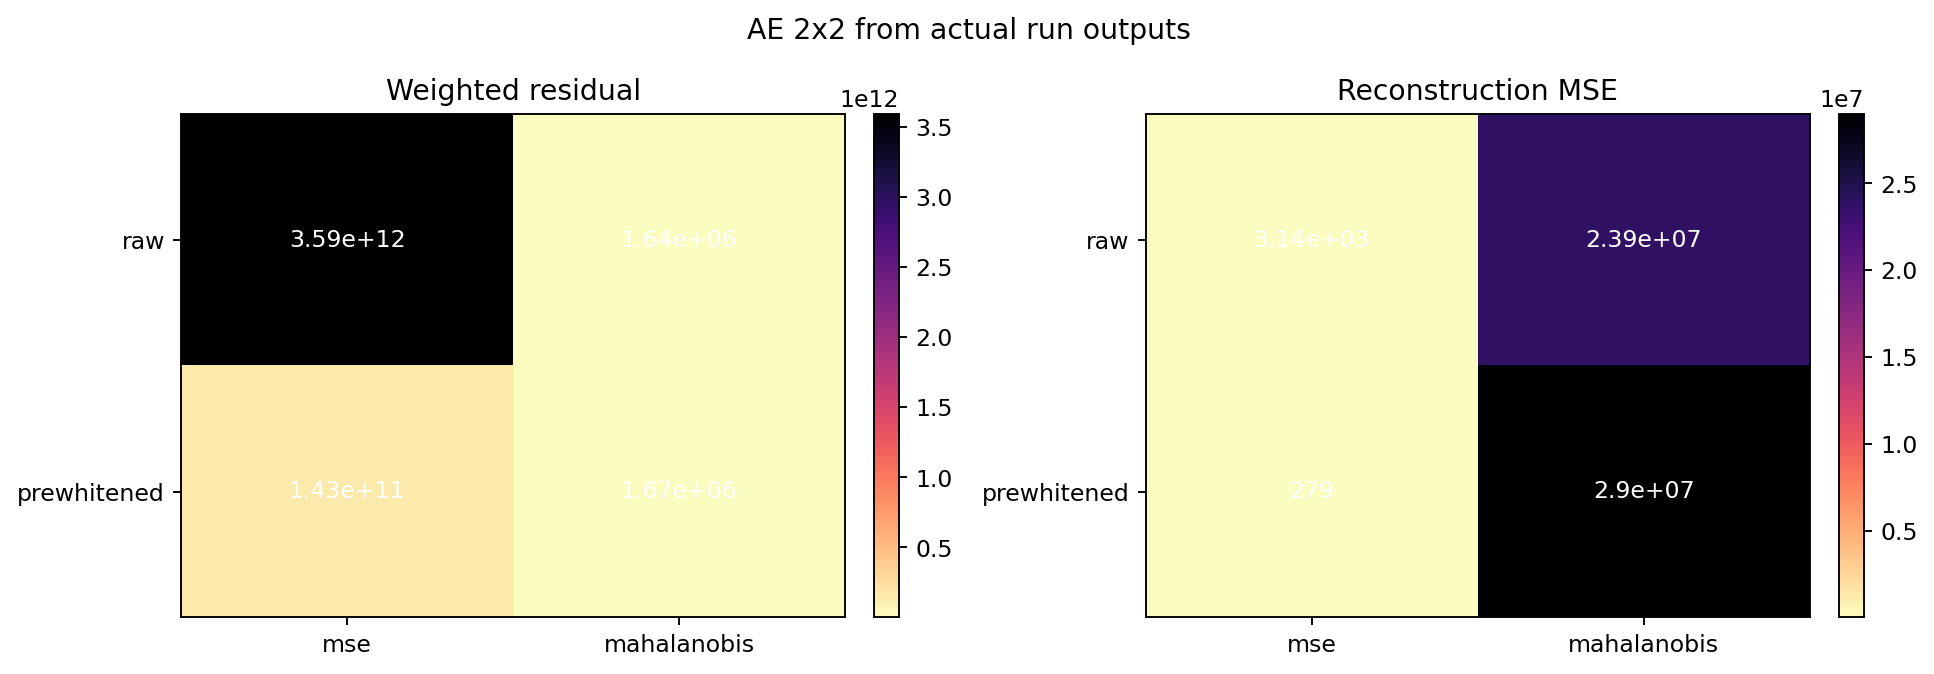

/ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results/_analysis/latest/figures/transformer_2x2_actual.png


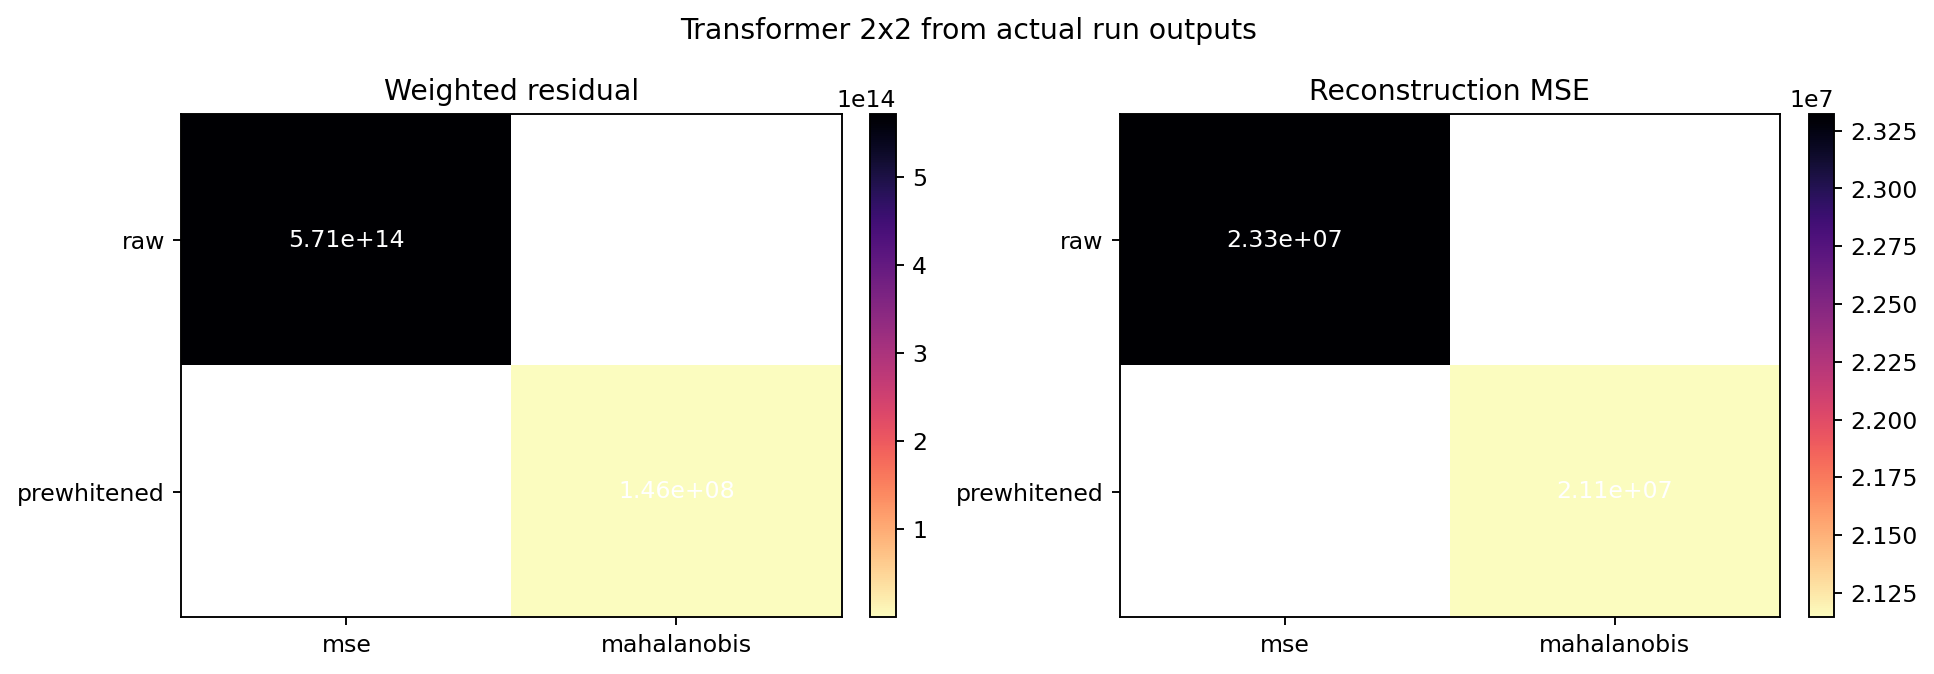

/ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results/_analysis/latest/figures/architecture_actual.png


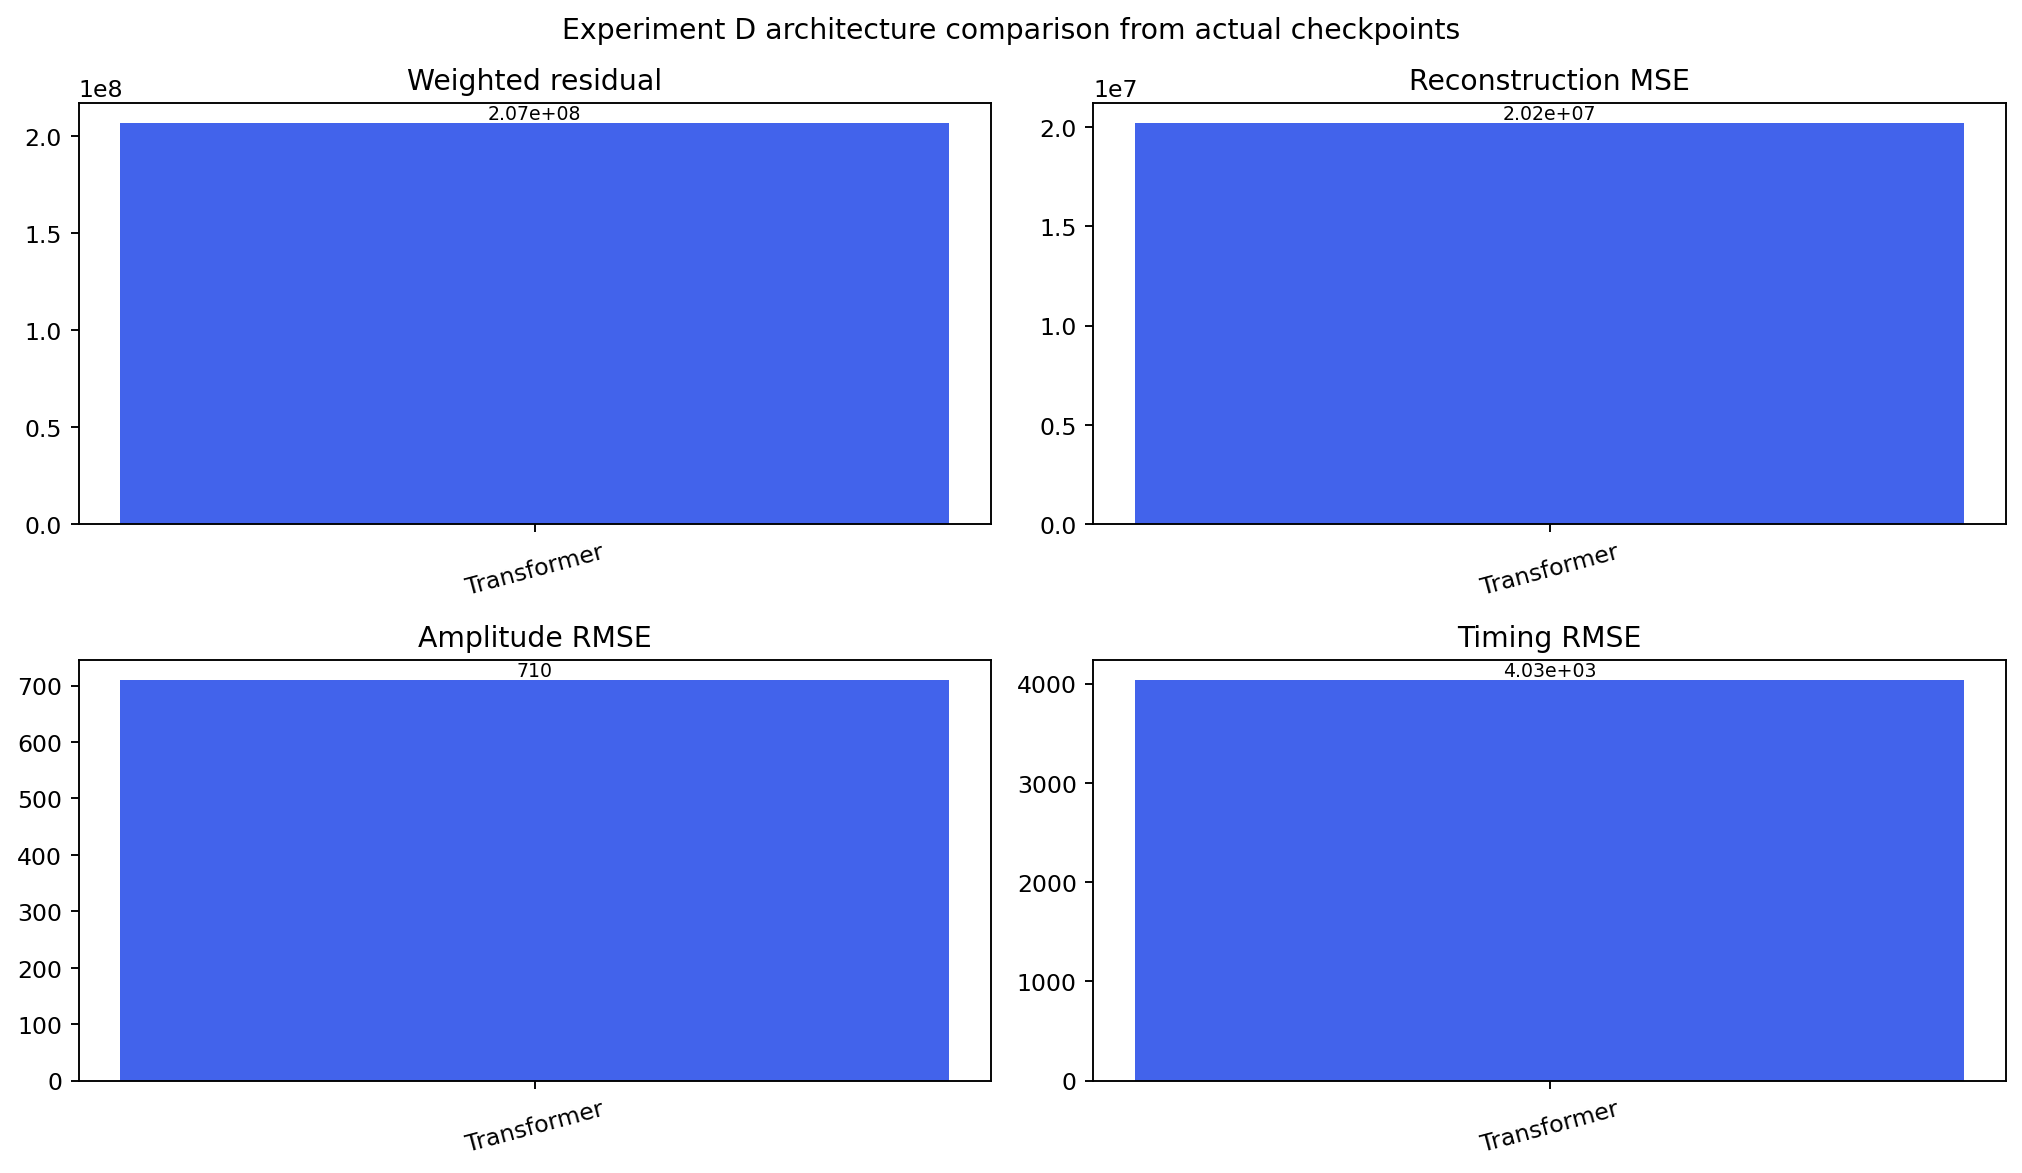

/ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results/_analysis/latest/figures/learning_curves_actual.png


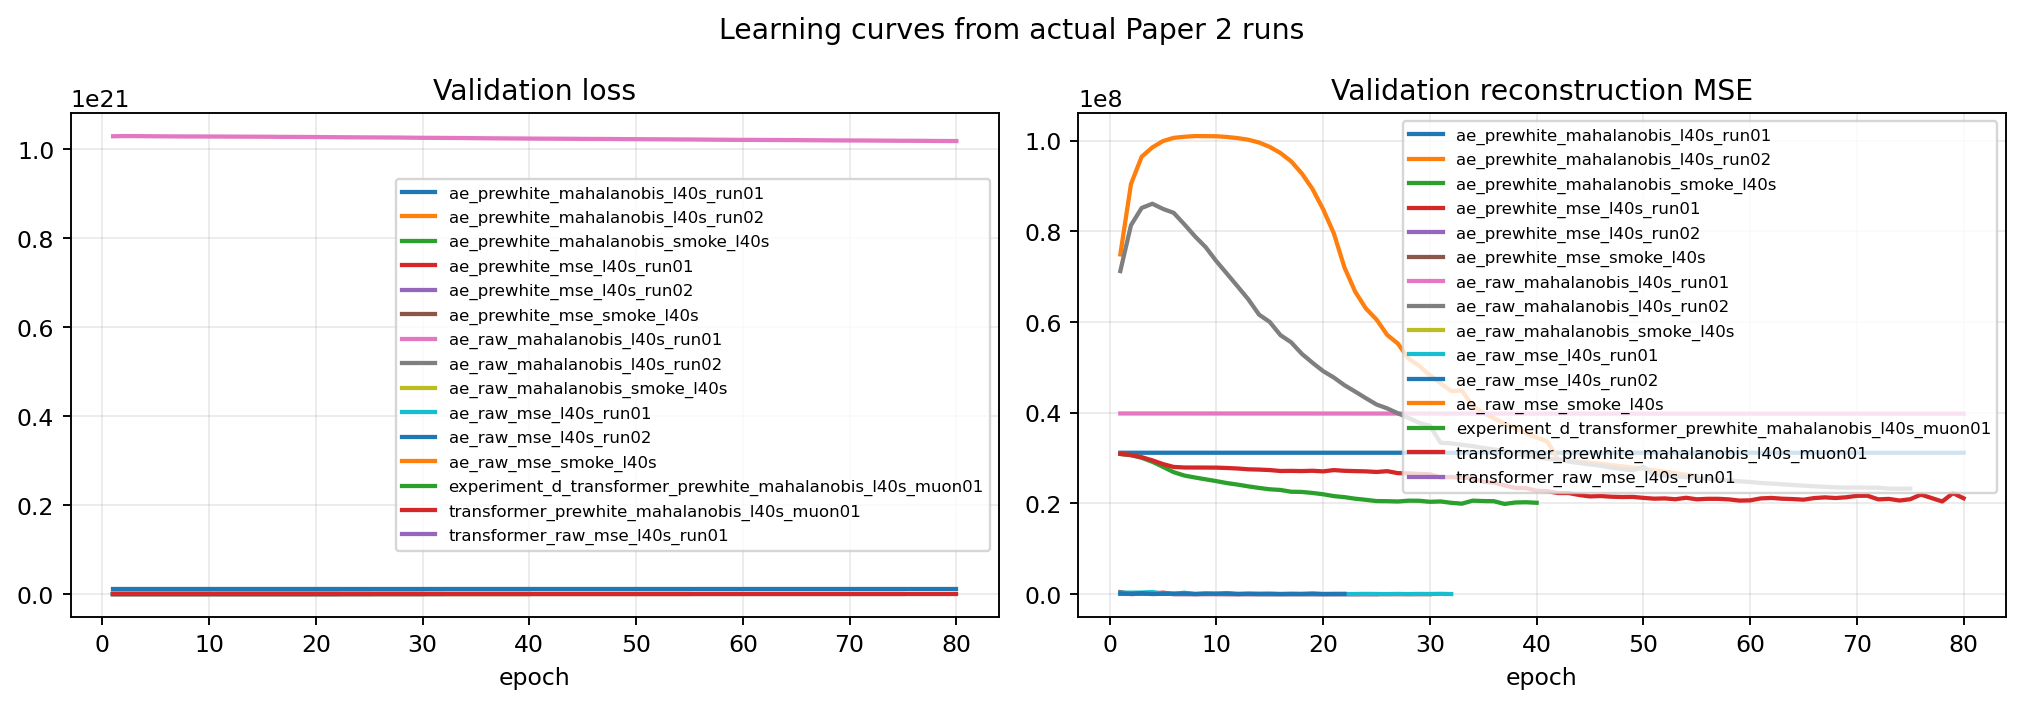

In [27]:
figure_names = [
    "ae_2x2_actual.png",
    "transformer_2x2_actual.png",
    "architecture_actual.png",
    "learning_curves_actual.png",
]

for name in figure_names:
    path = analysis_paths.figures_dir / name
    print(path)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("missing")

## Best-Run Metrics for Slides

This view is optimized for quickly copying headline numbers into slides or a draft.

In [28]:
slide_cols = [
    "experiment_name",
    "phase",
    "model_family",
    "input_mode",
    "loss_mode",
    "optimizer",
    "eval_loss",
    "weighted_residual_mean",
    "reconstruction_mse",
    "amplitude_rmse",
    "timing_rmse",
]
display(
    best_df[slide_cols]
    .sort_values(["phase", "model_family", "input_mode", "loss_mode"])
    .reset_index(drop=True)
)

,experiment_name,phase,model_family,input_mode,loss_mode,optimizer,eval_loss,weighted_residual_mean,reconstruction_mse,amplitude_rmse,timing_rmse
0,ae_prewhite_mahalanobis_l40s_run02,ae_2x2,ae,prewhitened,mahalanobis,adamw,1.667281e+06,1.667281e+06,2.897677e+07,20.461094,4034.908812
1,ae_prewhite_mse_l40s_run01,ae_2x2,ae,prewhitened,mse,adamw,2.788495e+02,1.433618e+11,2.788495e+02,40.981057,4034.908812
2,ae_raw_mahalanobis_l40s_run02,ae_2x2,ae,raw,mahalanobis,adamw,1.644403e+06,1.644403e+06,2.393367e+07,3.669252,4034.908812
3,ae_raw_mse_l40s_run01,ae_2x2,ae,raw,mse,adamw,3.141652e+03,3.591786e+12,3.141652e+03,110.200541,4034.908812
4,experiment_d_transformer_prewhite_mahalanobis_...,architecture,transformer,prewhitened,mahalanobis,adamw_muon,2.066123e+08,2.066123e+08,2.019627e+07,709.656542,4034.908812
5,transformer_raw_mse_l40s_run02,other,unknown,unknown,unknown,unknown,NaN,NaN,NaN,NaN,NaN
6,transformer_prewhite_mahalanobis_l40s_muon01,transformer_2x2,transformer,prewhitened,mahalanobis,adamw_muon,1.463549e+08,1.463549e+08,2.114371e+07,545.140176,4034.908812
7,transformer_raw_mse_l40s_run01,transformer_2x2,transformer,raw,mse,adamw,2.332030e+07,5.708791e+14,2.332030e+07,9837.621962,4919.166338


## Focused Comparisons

These slices are useful for talk framing:

- geometry effect inside the transformer 2x2;
- best AE vs best transformer;
- architecture-bias comparison at fixed prewhitened + Mahalanobis geometry.

In [29]:
transformer_2x2 = best_df[best_df["model_family"] == "transformer"].copy()
ae_2x2 = best_df[best_df["model_family"] == "ae"].copy()
architecture = best_df[best_df["phase"] == "architecture"].copy()

print("Transformer 2x2")
display(transformer_2x2.sort_values(["input_mode", "loss_mode"]).reset_index(drop=True))

print("AE 2x2")
display(ae_2x2.sort_values(["input_mode", "loss_mode"]).reset_index(drop=True))

print("Architecture comparison")
display(architecture.sort_values(["model_family", "experiment_name"]).reset_index(drop=True))

Transformer 2x2


,logical_group,experiment_name,phase,model_family,model_family_display,input_mode,loss_mode,optimizer,latent_dim,run_dir,...,has_metrics_json,has_analysis_metrics,eval_loss,weighted_residual_mean,reconstruction_mse,amplitude_rmse,timing_rmse,of_reference_amplitude_rmse,of_reference_timing_rmse,best_epoch
0,architecture|transformer|prewhitened|mahalanobis,experiment_d_transformer_prewhite_mahalanobis_...,architecture,transformer,Transformer,prewhitened,mahalanobis,adamw_muon,128.0,experiment_d_transformer_prewhite_mahalanobis_...,...,True,True,2.066123e+08,2.066123e+08,2.019627e+07,709.656542,4034.908812,698.066054,0.000000,NaN
1,transformer_2x2|transformer|prewhitened|mahala...,transformer_prewhite_mahalanobis_l40s_muon01,transformer_2x2,transformer,Transformer,prewhitened,mahalanobis,adamw_muon,128.0,transformer_prewhite_mahalanobis_l40s_muon01,...,True,True,1.463549e+08,1.463549e+08,2.114371e+07,545.140176,4034.908812,533.537312,0.000000,NaN
2,transformer_2x2|transformer|raw|mse,transformer_raw_mse_l40s_run01,transformer_2x2,transformer,Transformer,raw,mse,adamw,128.0,transformer_raw_mse_l40s_run01,...,True,True,2.332030e+07,5.708791e+14,2.332030e+07,9837.621962,4919.166338,9826.017015,1563.348264,NaN


AE 2x2


,logical_group,experiment_name,phase,model_family,model_family_display,input_mode,loss_mode,optimizer,latent_dim,run_dir,...,has_metrics_json,has_analysis_metrics,eval_loss,weighted_residual_mean,reconstruction_mse,amplitude_rmse,timing_rmse,of_reference_amplitude_rmse,of_reference_timing_rmse,best_epoch
0,ae_2x2|ae|prewhitened|mahalanobis,ae_prewhite_mahalanobis_l40s_run02,ae_2x2,ae,AE,prewhitened,mahalanobis,adamw,256.0,ae_prewhite_mahalanobis_l40s_run02,...,True,True,1.667281e+06,1.667281e+06,2.897677e+07,20.461094,4034.908812,8.652741,0.0,NaN
1,ae_2x2|ae|prewhitened|mse,ae_prewhite_mse_l40s_run01,ae_2x2,ae,AE,prewhitened,mse,adamw,256.0,ae_prewhite_mse_l40s_run01,...,True,True,2.788495e+02,1.433618e+11,2.788495e+02,40.981057,4034.908812,29.253347,0.0,NaN
2,ae_2x2|ae|raw|mahalanobis,ae_raw_mahalanobis_l40s_run02,ae_2x2,ae,AE,raw,mahalanobis,adamw,256.0,ae_raw_mahalanobis_l40s_run02,...,True,True,1.644403e+06,1.644403e+06,2.393367e+07,3.669252,4034.908812,13.106231,0.0,NaN
3,ae_2x2|ae|raw|mse,ae_raw_mse_l40s_run01,ae_2x2,ae,AE,raw,mse,adamw,256.0,ae_raw_mse_l40s_run01,...,True,True,3.141652e+03,3.591786e+12,3.141652e+03,110.200541,4034.908812,98.549033,0.0,NaN


Architecture comparison


,logical_group,experiment_name,phase,model_family,model_family_display,input_mode,loss_mode,optimizer,latent_dim,run_dir,...,has_metrics_json,has_analysis_metrics,eval_loss,weighted_residual_mean,reconstruction_mse,amplitude_rmse,timing_rmse,of_reference_amplitude_rmse,of_reference_timing_rmse,best_epoch
0,architecture|transformer|prewhitened|mahalanobis,experiment_d_transformer_prewhite_mahalanobis_...,architecture,transformer,Transformer,prewhitened,mahalanobis,adamw_muon,128.0,experiment_d_transformer_prewhite_mahalanobis_...,...,True,True,2.066123e+08,2.066123e+08,2.019627e+07,709.656542,4034.908812,698.066054,0.0,NaN


## Talk Support Figures

Recommended slide additions from the current talk draft:

- Slides 3-5: QP clean-family, likelihood geometry, and a fixed-template limitation plot to motivate why OF is a constrained likelihood solution.
- Slides 8 and 13: AE decision and smoothed residual-spectrum plots to show that linear/AE reconstruction must be judged in detector geometry, not native MSE alone.
- Slides 9 and 14: QP structured-noise plots to separate the clean Gaussian theorem from stress tests with non-stationarity, artifacts, and correlations.
- Slides 11-15: Transformer tokenization and latent-activation diagnostics to motivate channel-time models without claiming current transformer performance wins.
- Backup or conclusion: metric tradeoff, amplitude calibration, and NPML readiness figures.

All figures are written under `analysis_paths.figures_dir / "talk_support"`.


In [ ]:
from pathlib import Path
import math

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

try:
    TALK_FIG_DIR = analysis_paths.figures_dir / "talk_support"
except NameError:
    TALK_FIG_DIR = Path("/ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results/_analysis/latest/figures/talk_support")
TALK_FIG_DIR.mkdir(parents=True, exist_ok=True)

try:
    summary_df
except NameError:
    summary_df = pd.read_csv(TALK_FIG_DIR.parents[1] / "tables" / "run_summary.csv")
try:
    best_df
except NameError:
    best_df = pd.read_csv(TALK_FIG_DIR.parents[1] / "tables" / "best_by_logical_group.csv")

RUNS_DIR = Path("/ceph/dwong/noise-weighted-subspace-reconstruction/paper2/results")

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

palette = {
    "raw + mse": "#4C78A8",
    "raw + mahalanobis": "#F58518",
    "prewhitened + mse": "#54A24B",
    "prewhitened + mahalanobis": "#B279A2",
    "transformer": "#E45756",
}


def _clean_runs(df):
    out = df.copy()
    out = out[~out["experiment_name"].str.contains("smoke", case=False, na=False)]
    out = out[out["model_family"].isin(["ae", "transformer", "cnn_ae", "linear_ae"])]
    return out


def _condition_label(row):
    return f"{row['input_mode']} + {row['loss_mode']}"


def _save(fig, name):
    path = TALK_FIG_DIR / name
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path


def _log_bin_median(freq, values, n_bins=90):
    freq = np.asarray(freq, dtype=float)
    values = np.asarray(values, dtype=float)
    ok = np.isfinite(freq) & np.isfinite(values) & (freq > 0) & (values > 0)
    freq = freq[ok]
    values = values[ok]
    edges = np.geomspace(freq.min(), freq.max(), n_bins + 1)
    centers = np.sqrt(edges[:-1] * edges[1:])
    binned = np.full(n_bins, np.nan)
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        mask = (freq >= lo) & (freq < hi)
        if np.any(mask):
            binned[i] = np.nanmedian(values[mask])
    ok = np.isfinite(binned)
    return centers[ok], binned[ok]


def _toy_pulse(t, t0=0.0, rise=0.08, decay=1.6):
    dt = np.maximum(t - t0, 0.0)
    pulse = (1.0 - np.exp(-dt / rise)) * np.exp(-dt / decay)
    peak = np.max(pulse)
    return pulse / peak if peak > 0 else pulse

# 1. Likelihood geometry illustration for slides 4-8.
fig, ax = plt.subplots(figsize=(7.4, 4.0))
theta = np.linspace(0, 2 * np.pi, 400)
for r in [1.0, 2.0, 3.0]:
    ax.plot(r * np.cos(theta), r * np.sin(theta), color="#4C78A8", lw=1.25, alpha=0.55)
rot = np.array([[np.cos(0.55), -np.sin(0.55)], [np.sin(0.55), np.cos(0.55)]])
scale = np.diag([3.0, 0.85])
for r in [1.0, 2.0]:
    pts = rot @ scale @ np.vstack([r * np.cos(theta), r * np.sin(theta)])
    ax.plot(pts[0], pts[1], color="#F58518", lw=1.7, alpha=0.75)
ax.plot([-3.2, 3.2], [-1.45, 1.45], color="#333333", lw=2.2, label="fixed template")
curve_x = np.linspace(-3.1, 3.1, 150)
curve_y = 0.28 * curve_x**2 - 1.0
ax.plot(curve_x, curve_y, color="#54A24B", lw=2.4, label="learned manifold")
ax.arrow(-2.2, -1.0, 3.0, 1.55, width=0.02, head_width=0.14, length_includes_head=True, color="#222222")
ax.text(-3.45, 2.75, "white-noise\nmetric", color="#28507A", ha="left", va="top", fontsize=12)
ax.text(1.65, -2.75, "detector-noise\nmetric", color="#9A5A0A", ha="left", va="bottom", fontsize=12)
ax.text(-2.1, -0.98, "residual", color="#222222", rotation=27, fontsize=11)
ax.set_title("Likelihood geometry: which residuals count?", pad=10)
ax.set_xlabel("mode 1")
ax.set_ylabel("mode 2")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.9, 3.9)
ax.set_ylim(-3.05, 3.05)
ax.legend(loc="upper right", frameon=False)
geometry_path = _save(fig, "talk_likelihood_geometry_cartoon.png")

# 2. AE: make the metric decision visible instead of showing only a 2x2 table.
ae = best_df[(best_df["phase"] == "ae_2x2") & (best_df["model_family"] == "ae")].copy()
ae = ae[~ae["experiment_name"].str.contains("smoke", case=False, na=False)]
ae["condition"] = ae.apply(_condition_label, axis=1)
ae_order = [
    "raw + mse",
    "raw + mahalanobis",
    "prewhitened + mse",
    "prewhitened + mahalanobis",
]
ae_labels = ["raw\nMSE", "raw\nMaha", "prewhite\nMSE", "prewhite\nMaha"]
ae_plot = ae.set_index("condition").reindex(ae_order).reset_index()
bar_colors = [palette.get(label, "#777777") for label in ae_order]

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.7), constrained_layout=True)
panel_specs = [
    ("reconstruction_mse", "Native MSE\n(lower looks best)", True),
    ("weighted_residual_mean", "Detector likelihood residual\n(lower is best)", True),
    ("amplitude_rmse", "OF amplitude RMSE after AE\n(lower is best)", False),
]
for ax, (metric, title, use_log) in zip(axes, panel_specs):
    values = ae_plot[metric].astype(float).to_numpy()
    heights = np.log10(values) if use_log else values
    ax.bar(np.arange(len(values)), heights, color=bar_colors, edgecolor="white", linewidth=0.8)
    best_idx = int(np.nanargmin(values))
    ax.scatter(best_idx, heights[best_idx], s=170, marker="*", color="#222222", zorder=5)
    for i, value in enumerate(values):
        label = f"{np.log10(value):.1f}" if use_log else f"{value:.1f}"
        ax.text(i, heights[i], label, ha="center", va="bottom", fontsize=8)
    ax.set_xticks(np.arange(len(ae_labels)), ae_labels)
    ax.set_title(title)
    ax.set_ylabel("log10 value" if use_log else "amplitude units")
    ax.grid(axis="y", color="#dddddd", lw=0.7, alpha=0.8)
    ax.margins(y=0.22)
axes[0].text(0.03, 0.94, "native MSE rewards smooth fits", transform=axes[0].transAxes, ha="left", va="top", fontsize=9, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cccccc", alpha=0.9))
axes[1].text(0.03, 0.94, "likelihood rewards detector-weighted fits", transform=axes[1].transAxes, ha="left", va="top", fontsize=9, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cccccc", alpha=0.9))
axes[2].text(0.03, 0.94, "downstream amplitude can choose differently", transform=axes[2].transAxes, ha="left", va="top", fontsize=9, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cccccc", alpha=0.9))
fig.suptitle("AE comparison: the winning model depends on the geometry you care about", fontsize=13)
ae_decision_path = _save(fig, "talk_ae_metric_decision_panel.png")

# 2b. AE residual spectrum: where residuals are cheap vs expensive under the detector PSD.
psd_path = Path("/ceph/dwong/noise-weighted-subspace-reconstruction/data/Noise_PSD/noise_psd_from_MMC.npy")
psd = np.load(psd_path).astype(float)
freq = np.linspace(0.0, 0.5, len(psd))
residual_runs = [
    ("ae_raw_mse_l40s_run01", "raw + MSE", palette["raw + mse"]),
    ("ae_raw_mahalanobis_l40s_run02", "raw + Mahalanobis", palette["raw + mahalanobis"]),
    ("ae_prewhite_mse_l40s_run01", "prewhite + MSE", palette["prewhitened + mse"]),
    ("ae_prewhite_mahalanobis_l40s_run02", "prewhite + Mahalanobis", palette["prewhitened + mahalanobis"]),
]
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.9), constrained_layout=True)
binned_specs = {}
for run_name, label, color in residual_runs:
    with h5py.File(RUNS_DIR / run_name / "predictions_test.h5", "r") as handle:
        residual = handle["x_true"][:128, 0, :] - handle["x_hat"][:128, 0, :]
    spec = np.median(np.abs(np.fft.rfft(residual, axis=-1)) ** 2, axis=0)
    spec = spec / np.nanmedian(spec[1:])
    weighted_spec = spec / np.maximum(psd / np.nanmedian(psd[1:]), 1e-12)
    f_raw, raw_bin = _log_bin_median(freq[1:], spec[1:], n_bins=72)
    f_weighted, weighted_bin = _log_bin_median(freq[1:], weighted_spec[1:], n_bins=72)
    binned_specs[label] = (f_raw, raw_bin, f_weighted, weighted_bin)
    axes[0].plot(f_raw, raw_bin, color=color, lw=2.0, label=label)
    axes[1].plot(f_weighted, weighted_bin, color=color, lw=2.0, label=label)
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", color="#dddddd", lw=0.6, alpha=0.65)
    ax.set_xlabel("normalized frequency")
    ax.axvspan(4e-5, 4e-4, color="#F58518", alpha=0.12, zorder=-1)
axes[0].set_title("Raw residual spectrum\n(log-binned median)")
axes[0].set_ylabel("median residual power, normalized")
axes[1].set_title("Same residuals after detector-PSD weighting")
axes[1].set_ylabel("residual power / PSD, normalized")
axes[1].legend(loc="upper right", frameon=False)
axes[0].text(0.04, 0.08, "low-frequency residuals\nlook smooth in native space", transform=axes[0].transAxes, fontsize=9, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cccccc", alpha=0.9))
axes[1].text(0.04, 0.08, "the same band is costly\nunder the detector PSD", transform=axes[1].transAxes, fontsize=9, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cccccc", alpha=0.9))
fig.suptitle("AE residual spectra: weighting by the detector PSD changes which errors matter", fontsize=13)
ae_spectrum_path = _save(fig, "talk_ae_residual_spectrum.png")

# 3. Tradeoff scatter, decluttered for a backup/key-result slide.
scatter_df = _clean_runs(summary_df)
scatter_df = scatter_df[np.isfinite(scatter_df["reconstruction_mse"]) & np.isfinite(scatter_df["weighted_residual_mean"])]
fig, ax = plt.subplots(figsize=(7.7, 4.8))
for _, row in scatter_df.iterrows():
    label = _condition_label(row)
    color = palette.get(label, "#777777")
    marker = "s" if row["model_family"] == "transformer" else "o"
    size = 105 if row["model_family"] == "transformer" else 80
    ax.scatter(row["reconstruction_mse"], row["weighted_residual_mean"], s=size, color=color, marker=marker, edgecolor="white", linewidth=0.8, alpha=0.88)
label_positions = {
    "ae_raw_mse_l40s_run01": ("raw MSE", 12, 8),
    "ae_raw_mahalanobis_l40s_run02": ("raw Maha", -76, 18),
    "ae_prewhite_mse_l40s_run01": ("prewhite MSE", 10, 10),
    "ae_prewhite_mahalanobis_l40s_run02": ("prewhite Maha", 8, 20),
    "transformer_raw_mse_l40s_run01": ("Transformer raw", -86, 12),
    "transformer_prewhite_mahalanobis_l40s_muon01": ("Transformer prewhite", -110, -14),
}
for _, row in scatter_df.iterrows():
    spec = label_positions.get(row["experiment_name"])
    if spec is not None:
        text, dx, dy = spec
        ax.annotate(text, (row["reconstruction_mse"], row["weighted_residual_mean"]), xytext=(dx, dy), textcoords="offset points", fontsize=8, arrowprops=dict(arrowstyle="-", lw=0.7, color="#777777"))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("native-space reconstruction MSE")
ax.set_ylabel("detector-weighted residual, summed over samples")
ax.set_ylim(4e5, 2.5e17)
ax.set_title("Native error and detector-likelihood error rank runs differently")
condition_handles = [
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=palette[name], markeredgecolor="white", label=name, markersize=8)
    for name in ["raw + mse", "raw + mahalanobis", "prewhitened + mse", "prewhitened + mahalanobis"]
]
model_handles = [
    plt.Line2D([0], [0], marker="o", color="#555555", linestyle="none", label="AE", markersize=7),
    plt.Line2D([0], [0], marker="s", color="#555555", linestyle="none", label="Transformer", markersize=7),
]
leg1 = ax.legend(handles=condition_handles, loc="lower left", bbox_to_anchor=(0.0, -0.34), frameon=False, ncol=2, title="condition")
ax.add_artist(leg1)
ax.legend(handles=model_handles, loc="upper left", frameon=True, framealpha=0.9, title="marker")
tradeoff_path = _save(fig, "talk_metric_tradeoff_scatter.png")

# 4. Amplitude calibration.
selected_runs = [
    ("ae_raw_mse_l40s_run01", "AE raw + MSE"),
    ("ae_raw_mahalanobis_l40s_run02", "AE raw + Mahalanobis"),
    ("ae_prewhite_mse_l40s_run01", "AE prewhite + MSE"),
    ("ae_prewhite_mahalanobis_l40s_run02", "AE prewhite + Mahalanobis"),
]
fig, axes = plt.subplots(2, 2, figsize=(8.4, 6.2), sharex=True, sharey=True, constrained_layout=True)
for ax, (run_name, title) in zip(axes.ravel(), selected_runs):
    with h5py.File(RUNS_DIR / run_name / "predictions_test.h5", "r") as handle:
        ref = handle["amplitude"][:]
        pred = handle["of_amplitude_pred"][:]
    resid = pred - ref
    rmse = float(np.sqrt(np.mean(resid**2)))
    ax.scatter(ref, resid, s=14, alpha=0.55, color="#4C78A8", edgecolor="none")
    ax.axhline(0, color="#222222", lw=1.0)
    ax.set_title(f"{title}\nRMSE={rmse:.1f}")
    ax.set_xlabel("reference amplitude")
    ax.set_ylabel("predicted - reference")
fig.suptitle("Amplitude calibration after reconstruction", fontsize=13)
amplitude_path = _save(fig, "talk_amplitude_calibration_panels.png")

# 5. OF/fixed-template limitation: one template cannot represent timing and decay variation.
toy_time = np.linspace(-0.6, 6.0, 1400)
template = _toy_pulse(toy_time, t0=0.0, rise=0.08, decay=1.6)
variants = [
    ("early, short decay", _toy_pulse(toy_time, t0=-0.08, rise=0.08, decay=1.05), "#4C78A8"),
    ("template event", template, "#222222"),
    ("late, long decay", _toy_pulse(toy_time, t0=0.16, rise=0.10, decay=2.45), "#F58518"),
]
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), constrained_layout=True)
for label, pulse, color in variants:
    amp = float(np.dot(template, pulse) / np.dot(template, template))
    fit = amp * template
    axes[0].plot(toy_time, pulse, color=color, lw=2.0, label=label)
    if label != "template event":
        axes[1].plot(toy_time, pulse - fit, color=color, lw=2.0, label=f"{label} residual")
axes[0].plot(toy_time, template, color="#222222", lw=2.6, ls="--", label="fixed OF template")
axes[0].set_title("Signal family vs one fixed template")
axes[0].set_xlabel("time, arbitrary units")
axes[0].set_ylabel("normalized pulse height")
axes[0].legend(loc="upper right", frameon=False)
axes[1].axhline(0, color="#222222", lw=1.0)
axes[1].set_title("Best amplitude fit leaves structured residuals")
axes[1].set_xlabel("time, arbitrary units")
axes[1].set_ylabel("pulse - best template fit")
axes[1].legend(loc="lower right", frameon=False)
fig.suptitle("Optimal Filter is maximum likelihood only inside a fixed-template model", fontsize=13)
of_template_path = _save(fig, "talk_of_fixed_template_limitation.png")

# 5b. Backup: baseline-aligned waveform overlay for AE shape comparison.

trace_runs = [
    ("ae_raw_mse_l40s_run01", "raw + MSE"),
    ("ae_raw_mahalanobis_l40s_run02", "raw + Mahalanobis"),
    ("ae_prewhite_mse_l40s_run01", "prewhite + MSE"),
    ("ae_prewhite_mahalanobis_l40s_run02", "prewhite + Mahalanobis"),
]
with h5py.File(RUNS_DIR / trace_runs[0][0] / "predictions_test.h5", "r") as handle:
    err = np.mean((handle["x_true"][:, 0, :] - handle["x_hat"][:, 0, :]) ** 2, axis=1)
    event_idx = int(np.argsort(err)[len(err) // 2])
trace_slice = slice(2500, 7000)
time = np.arange(trace_slice.start, trace_slice.stop)
fig, axes = plt.subplots(len(trace_runs), 1, figsize=(8.6, 7.2), sharex=True, constrained_layout=True)
for ax, (run_name, title) in zip(axes, trace_runs):
    with h5py.File(RUNS_DIR / run_name / "predictions_test.h5", "r") as handle:
        true = handle["x_true"][event_idx, 0, trace_slice]
        pred = handle["x_hat"][event_idx, 0, trace_slice]
    pred = pred + np.median(true[:300]) - np.median(pred[:300])
    residual = true - pred
    ax.plot(time, true, color="#222222", lw=1.3, label="true")
    ax.plot(time, pred, color="#E45756", lw=1.1, label="reconstruction, baseline aligned")
    ax.plot(time, residual, color="#4C78A8", lw=0.9, alpha=0.9, label="residual")
    ax.set_title(title, loc="left")
    ax.set_ylabel("ADC")
axes[-1].set_xlabel("sample index")
axes[0].legend(loc="upper right", frameon=False, ncol=3)
fig.suptitle(f"Held-out trace shape reconstruction, event index {event_idx}", fontsize=13)
waveform_path = _save(fig, "talk_waveform_reconstruction_overlay.png")

# 6. Transformer: tokenization and latent-activation diagnostics for architecture motivation.
transformer_run = RUNS_DIR / "transformer_prewhite_mahalanobis_l40s_muon01" / "predictions_test.h5"
transformer_paths = []
if transformer_run.exists():
    with h5py.File(transformer_run, "r") as handle:
        event_scores = np.mean((handle["x_true"][:, 0, :] - handle["x_hat"][:, 0, :]) ** 2, axis=1)
        event_idx = int(np.argsort(event_scores)[len(event_scores) // 2])
        true_trace = handle["x_true"][event_idx, 0]
        z = handle["z"][event_idx]
    if z.ndim == 3:
        z_map = np.linalg.norm(z, axis=-1)
    else:
        z_map = np.linalg.norm(z.reshape(1, -1, z.shape[-1]), axis=-1)
    token_energy = z_map / max(float(np.nanmax(z_map)), 1e-12)
    n_channels, n_tokens = token_energy.shape
    token_edges = np.linspace(0, len(true_trace), n_tokens + 1, dtype=int)
    token_rms = np.array([
        np.sqrt(np.mean(true_trace[token_edges[i]:token_edges[i + 1]] ** 2))
        for i in range(n_tokens)
    ])
    token_rms = token_rms / max(float(np.nanmax(token_rms)), 1e-12)
    trace_slice = slice(2200, 7200)
    t = np.arange(trace_slice.start, trace_slice.stop)

    fig, axes = plt.subplots(3, 1, figsize=(9.0, 6.2), sharex=False, constrained_layout=True, gridspec_kw={"height_ratios": [1.2, 0.75, 1.25]})
    axes[0].plot(t, true_trace[trace_slice], color="#222222", lw=1.25)
    for edge in token_edges:
        if trace_slice.start <= edge <= trace_slice.stop:
            axes[0].axvline(edge, color="#B0B0B0", lw=0.45, alpha=0.55)
    axes[0].text(0.02, 0.92, "vertical lines = token boundaries", transform=axes[0].transAxes, ha="left", va="top", fontsize=9, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cccccc", alpha=0.9))
    axes[0].set_title("Held-out trace divided into time tokens")
    axes[0].set_ylabel("ADC")
    axes[1].imshow(token_rms[None, :], aspect="auto", cmap="Greys", vmin=0, vmax=1)
    axes[1].set_yticks([])
    axes[1].set_title("token RMS from the trace")
    axes[1].set_xlabel("time token")
    im = axes[2].imshow(token_energy, aspect="auto", cmap="magma", vmin=0, vmax=1)
    axes[2].set_title("latent activation energy after transformer encoder")
    axes[2].set_xlabel("time token")
    axes[2].set_ylabel("channel token")
    if n_channels == 1:
        axes[2].set_ylabel("single-channel token")
    axes[2].set_yticks(np.arange(n_channels))
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.024, pad=0.02)
    cbar.set_label("relative energy")
    fig.suptitle("Transformer motivation: tokenize the trace, then diagnose latent activations", fontsize=13)
    tokenization_path = _save(fig, "talk_transformer_tokenization_schematic.png")
    transformer_paths.append(tokenization_path)

    fig, ax = plt.subplots(figsize=(8.2, 3.1), constrained_layout=True)
    im = ax.imshow(token_energy, aspect="auto", cmap="magma", vmin=0, vmax=1)
    peak_ch, peak_tok = np.unravel_index(int(np.nanargmax(token_energy)), token_energy.shape)
    ax.scatter([peak_tok], [peak_ch], s=130, facecolor="none", edgecolor="cyan", linewidth=1.8)
    ax.annotate("largest latent activation", xy=(peak_tok, peak_ch), xytext=(min(peak_tok + 14, n_tokens - 1), peak_ch + 0.15), arrowprops=dict(arrowstyle="->", color="cyan", lw=1.2), color="white", fontsize=9)
    ax.set_title("Latent activation energy by token (diagnostic, not attention)")
    ax.set_xlabel("time token")
    ax.set_ylabel("channel token")
    if n_channels == 1:
        ax.set_ylabel("single-channel token")
    ax.set_yticks(np.arange(n_channels))
    cbar = fig.colorbar(im, ax=ax, fraction=0.032, pad=0.02)
    cbar.set_label("relative latent energy")
    importance_path = _save(fig, "talk_transformer_latent_activation_map.png")
    transformer_paths.append(importance_path)
else:
    transformer_paths = []

created_paths = [
    geometry_path,
    ae_decision_path,
    ae_spectrum_path,
    tradeoff_path,
    amplitude_path,
    of_template_path,
    waveform_path,
    *transformer_paths,
]

for path in created_paths:
    print(path)
    display(Image(filename=str(path)))


## QP Simulator + Structured Noise Evidence

These plots are controlled stress tests for the talk and paper narrative. The strict EMPCA/likelihood theorem assumes stationary Gaussian noise with a known PSD; the QP simulator gives us a controlled signal manifold, and the NoiseGenerator stack lets us deliberately violate that assumption with non-stationarity, artifacts, channel correlation, and heavy tails.

Use these as supporting illustrations and robustness diagnostics, not as replacements for the real-run reconstruction figures above.

Recommended placement:

- `qp_clean_shape_family.png`: near the OF/PCA/EMPCA transition, to show why one fixed template is restrictive.
- `qp_noise_pipeline_examples.png` and `qp_noise_psd_shift.png`: near “correct loss is necessary, not sufficient.”
- `qp_artifact_before_after.png`: backup slide for non-Gaussian artifact limitations and flagging.
- `qp_multichannel_correlation.png`: architecture/noise-model motivation for channel-time methods.


In [ ]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
while not (ROOT / "QP_simulator" / "QPSimulator.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "QP_simulator" / "QPSimulator.py").exists():
    raise RuntimeError("Could not locate repository root containing QP_simulator/")
for path in (ROOT, ROOT / "QP_simulator"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from QP_simulator.QPSimulator import QPSimulator
from QP_simulator.noise_module.NoiseGenerator import NoiseGenerator
from QP_simulator.noise_module.artifact_injector import ArtifactInjector
from QP_simulator.noise_module.multichannel_noise import MultiChannelNoiseGenerator
from QP_simulator.noise_module.temporal_noise import TemporalNoiseWrapper

try:
    QP_TALK_FIG_DIR = analysis_paths.figures_dir / "talk_support" / "qp_simulator"
except NameError:
    QP_TALK_FIG_DIR = ROOT / "paper2" / "results" / "_analysis" / "latest" / "figures" / "talk_support" / "qp_simulator"
QP_TALK_FIG_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(20260610)
sim = QPSimulator(trace_samples=16_384)
fs = sim.frequency
N = sim.trace_samples
t_ms = np.arange(N) / fs * 1e3

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def _save(fig, name):
    path = QP_TALK_FIG_DIR / name
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path


def _quick_psd(x, fs):
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x[None, :]
    x = x - np.mean(x, axis=-1, keepdims=True)
    window = np.hanning(x.shape[-1])
    spec = np.fft.rfft(x * window[None, :], axis=-1)
    psd = (np.abs(spec) ** 2) / (fs * np.sum(window**2))
    freq = np.fft.rfftfreq(x.shape[-1], d=1.0 / fs)
    return freq, psd.mean(axis=0)

# 1. Controlled QP signal family: fixed-template OF is too restrictive when shape and timing vary.
clean_traces, truth = sim.generate_family(
    n_events=96,
    tau_decay_range=(1.2e6, 5.0e6),
    t0_jitter_range=(-2.5e5, 2.5e5),
    n_QP_range=(3500, 6500),
    rng=rng,
)
idx_low = int(np.argmin(truth["tau_decay"]))
idx_mid = int(np.argsort(truth["tau_decay"])[len(clean_traces) // 2])
idx_high = int(np.argmax(truth["tau_decay"]))
selected = [(idx_low, "short decay"), (idx_mid, "mid decay"), (idx_high, "long decay")]
fig, ax = plt.subplots(figsize=(7.8, 4.0))
for idx, label in selected:
    trace = clean_traces[idx]
    trace_norm = trace / max(np.max(np.abs(trace)), np.finfo(float).eps)
    ax.plot(t_ms, trace_norm, lw=1.8, label=f"{label}: tau={truth['tau_decay'][idx] * 1e-6:.1f} ms, shift={truth['t0_shift'][idx] * 1e-6:+.2f} ms")
ax.set_title("Controlled QP signal family: timing and pulse shape vary")
ax.set_xlabel("time [ms]")
ax.set_ylabel("normalized ADC")
ax.legend(frameon=False, loc="upper right")
qp_clean_path = _save(fig, "qp_clean_shape_family.png")

# 2. Composed noise pipeline: stationary baseline, temporal non-stationarity, artifacts/heavy tails.
base_config = {"noise_type": "pink", "noise_power": 16.0, "sampling_frequency": fs}
base_gen = NoiseGenerator(base_config, seed=11)
stationary_noise = base_gen.generate_noise(N)
clean = clean_traces[idx_mid]
stationary_noisy = clean + stationary_noise

temporal = TemporalNoiseWrapper(
    {
        "mode": "piecewise",
        "n_segments": 5,
        "crossfade_len": 128,
        "vary_noise_power": True,
        "noise_power_scale_range": [0.45, 1.8],
        "variance_modulation": True,
        "variance_scale_range": [0.75, 1.35],
        "add_drift": True,
        "drift_sigma": 0.7,
        "drift_n_knots": 7,
    },
    seed=12,
)
nonstationary_noise, temporal_meta = temporal.apply(np.zeros(N), base_generator=base_gen, return_metadata=True)
nonstationary_noisy = clean + nonstationary_noise

artifact = ArtifactInjector(
    {
        "sampling_frequency": fs,
        "enable_lines": True,
        "lines": [
            {"freq": 50.0, "amp": 2.5, "phase": "random", "harmonics": [1, 2]},
            {"freq": 420.0, "amp": 1.1, "phase": "random", "harmonics": [1]},
        ],
        "enable_glitches": True,
        "glitch_rate": 3.0,
        "glitch_amp_range": [15.0, 45.0],
        "glitch_duration_samples": [32, 160],
        "enable_bursts": True,
        "burst_rate": 1.5,
        "burst_amp_range": [10.0, 35.0],
        "burst_duration_samples": [96, 360],
        "enable_sparse_impulses": True,
        "impulse_probability": 8e-4,
        "impulse_sigma": 20.0,
    },
    seed=13,
)
artifacted_noisy, artifact_meta = artifact.apply(nonstationary_noisy, return_metadata=True)
artifact_only = artifacted_noisy - nonstationary_noisy

zoom = slice(0, min(N, 9000))
fig, axes = plt.subplots(4, 1, figsize=(8.4, 7.0), sharex=True, constrained_layout=True)
series = [
    (clean, "clean QP signal", "#222222"),
    (stationary_noisy, "clean + stationary pink Gaussian noise", "#4C78A8"),
    (nonstationary_noisy, "clean + piecewise non-stationary noise", "#54A24B"),
    (artifacted_noisy, "clean + non-stationary noise + artifacts", "#E45756"),
]
for ax, (y, title, color) in zip(axes, series):
    ax.plot(t_ms[zoom], y[zoom], lw=0.75, color=color)
    ax.set_title(title, loc="left")
    ax.set_ylabel("ADC")
axes[-1].set_xlabel("time [ms]")
fig.suptitle("QP + NoiseGenerator composition: controlled stress-test traces", fontsize=13)
qp_pipeline_path = _save(fig, "qp_noise_pipeline_examples.png")

# 3. PSD shift: global PSD hides segment-to-segment changes.
freq_base, psd_base = base_gen.build_psd(N)
freq_global, psd_global = QPSimulator.estimate_psd(nonstationary_noise[None, :], fs)
segment_edges = np.linspace(0, N, 6, dtype=int)
segment_psds = []
for start, end in zip(segment_edges[:-1], segment_edges[1:]):
    freq_seg, psd_seg = _quick_psd(nonstationary_noise[start:end], fs)
    segment_psds.append((freq_seg, psd_seg, start, end))
fig, ax = plt.subplots(figsize=(7.4, 4.5))
mask_base = freq_base > 0
mask_global = freq_global > 0
target_shape = psd_base.copy()
target_interp = np.interp(freq_global[mask_global], freq_base[mask_base], target_shape[mask_base])
scale_mask = (freq_global[mask_global] > 100) & (freq_global[mask_global] < 1.0e4)
target_scale = np.nanmedian(psd_global[mask_global][scale_mask]) / max(
    np.nanmedian(target_interp[scale_mask]),
    np.finfo(float).eps,
)
target_shape = target_shape * target_scale
ax.loglog(freq_base[mask_base], target_shape[mask_base], color="#222222", lw=1.8, label="stationary target PSD shape")
ax.loglog(freq_global[mask_global], psd_global[mask_global], color="#E45756", lw=1.8, label="global PSD estimate")
for freq_seg, psd_seg, start, end in segment_psds:
    mask = freq_seg > 0
    ax.loglog(freq_seg[mask], psd_seg[mask], lw=0.9, alpha=0.5, label=f"segment {start // (N // 5) + 1}")
ax.set_xlim(5, fs / 2)
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("PSD [a.u.]")
ax.set_title("Non-stationary noise: one global PSD is an approximation")
ax.legend(frameon=False, ncol=2)
qp_psd_path = _save(fig, "qp_noise_psd_shift.png")

# 4. Artifact before/after and simple flagging signal.
win_start = int(np.argmax(np.abs(artifact_only)) - 450)
win_start = max(0, min(win_start, N - 1200))
win = slice(win_start, win_start + 1200)
rolling_window = 128
local_energy = np.convolve(artifact_only**2, np.ones(rolling_window) / rolling_window, mode="same")
threshold = np.quantile(local_energy, 0.95)
fig, axes = plt.subplots(2, 1, figsize=(8.2, 5.0), sharex=True, constrained_layout=True)
axes[0].plot(t_ms[win], nonstationary_noisy[win], color="#4C78A8", lw=0.9, label="before artifacts")
axes[0].plot(t_ms[win], artifacted_noisy[win], color="#E45756", lw=0.9, label="after artifacts")
axes[0].set_ylabel("ADC")
axes[0].set_title("Transient artifacts create heavy-tail outliers")
axes[0].legend(frameon=False)
axes[1].plot(t_ms[win], local_energy[win], color="#222222", lw=1.0, label="local artifact energy")
axes[1].axhline(threshold, color="#E45756", ls="--", lw=1.0, label="flag threshold")
axes[1].fill_between(t_ms[win], 0, local_energy[win], where=local_energy[win] > threshold, color="#E45756", alpha=0.25)
axes[1].set_xlabel("time [ms]")
axes[1].set_ylabel("energy")
axes[1].legend(frameon=False)
qp_artifact_path = _save(fig, "qp_artifact_before_after.png")

# 5. Multichannel correlation: independent vs shared/private noise.
mc_config = {"mode": "shared_private", "n_channels": 8, "corr_strength": 0.42, "channel_gain_jitter": 0.05, "normalize_channel_variance": True}
mc = MultiChannelNoiseGenerator(base_config, config=mc_config, seed=14)
independent, independent_meta = mc.generate_independent(8, N, return_metadata=True)
correlated, correlated_meta = mc.generate_shared_private(8, N, corr_strength=0.42, return_metadata=True)
fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.7), constrained_layout=True)
for ax, X, title, meta in [
    (axes[0], independent, "independent channels", independent_meta),
    (axes[1], correlated, "shared/private correlated", correlated_meta),
]:
    im = ax.imshow(np.corrcoef(X), vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(f"{title}\nmean offdiag={meta['mean_offdiag_corr']:.2f}")
    ax.set_xlabel("channel")
    ax.set_ylabel("channel")
fig.colorbar(im, ax=axes, shrink=0.82, label="correlation")
fig.suptitle("Synthetic multichannel noise controls detector-correlation stress tests", fontsize=13)
qp_corr_path = _save(fig, "qp_multichannel_correlation.png")

# 6. Optional E10/E11 robustness summary from results/data_cache.h5.
cache_path = ROOT / "results" / "data_cache.h5"
robustness_paths = []
if cache_path.exists():
    with h5py.File(cache_path, "r") as handle:
        has_e10_e11 = "e10_e11" in handle
else:
    has_e10_e11 = False

if has_e10_e11:
    nonstationary_rows = []
    artifact_rows = []
    multichannel_rows = []
    with h5py.File(cache_path, "r") as handle:
        for seed_name, seed_group in handle["e10_e11"].items():
            seed = int(seed_name.replace("seed_", ""))
            if "nonstationary_df" in seed_group:
                group = seed_group["nonstationary_df"]
                cols = {key: group[key][()] for key in group.keys()}
                for idx in range(len(next(iter(cols.values())))):
                    row = {key: (value[idx].decode() if getattr(value, "dtype", None) is not None and value.dtype.kind in "SO" else value[idx]) for key, value in cols.items()}
                    row["seed"] = seed
                    nonstationary_rows.append(row)
            if "artifact_df" in seed_group:
                group = seed_group["artifact_df"]
                cols = {key: group[key][()] for key in group.keys()}
                for idx in range(len(next(iter(cols.values())))):
                    row = {key: (value[idx].decode() if getattr(value, "dtype", None) is not None and value.dtype.kind in "SO" else value[idx]) for key, value in cols.items()}
                    row["seed"] = seed
                    artifact_rows.append(row)
            if "multichannel_df" in seed_group:
                group = seed_group["multichannel_df"]
                cols = {key: group[key][()] for key in group.keys()}
                for idx in range(len(next(iter(cols.values())))):
                    row = {key: (value[idx].decode() if getattr(value, "dtype", None) is not None and value.dtype.kind in "SO" else value[idx]) for key, value in cols.items()}
                    row["seed"] = seed
                    multichannel_rows.append(row)
    if nonstationary_rows:
        ns_df = pd.DataFrame(nonstationary_rows)
        ns_summary = ns_df.groupby("case", as_index=False)["amplitude_rmse"].agg(["mean", "std"]).reset_index()
        fig, ax = plt.subplots(figsize=(6.6, 3.8))
        ax.bar(ns_summary["case"], ns_summary["mean"], yerr=ns_summary["std"].fillna(0), color="#4C78A8", alpha=0.88, capsize=4)
        ax.set_ylabel("amplitude RMSE")
        ax.set_title("E10 robustness: PSD handling under non-stationarity")
        ax.tick_params(axis="x", rotation=20)
        robustness_paths.append(_save(fig, "qp_e10_nonstationary_summary.png"))
    if artifact_rows:
        art_df = pd.DataFrame(artifact_rows)
        art_summary = art_df.groupby("pass", as_index=False)["amplitude_rmse"].agg(["mean", "std"]).reset_index()
        fig, ax = plt.subplots(figsize=(5.8, 3.8))
        ax.bar(art_summary["pass"], art_summary["mean"], yerr=art_summary["std"].fillna(0), color="#F58518", alpha=0.88, capsize=4)
        ax.set_ylabel("amplitude RMSE")
        ax.set_title("E11 robustness: contaminated fit vs flagged refit")
        robustness_paths.append(_save(fig, "qp_e11_artifact_summary.png"))
    if multichannel_rows:
        multi_df = pd.DataFrame(multichannel_rows)
        print("E10/E11 multichannel summary")
        display(multi_df)
else:
    print("E10/E11 robustness cache not found in results/data_cache.h5.")
    print("To generate robustness-summary bars, run from the repo root:")
    print("  python implementation/generate_data.py --robustness")
    print("Then rerun this notebook cell; it will load the e10_e11 group automatically.")

created_paths = [
    qp_clean_path,
    qp_pipeline_path,
    qp_psd_path,
    qp_artifact_path,
    qp_corr_path,
    *robustness_paths,
]

for path in created_paths:
    print(path)
    display(Image(filename=str(path)))


## Notes

- `metrics.json` is training-time best-run summary.
- `analysis_metrics.json` is the new checkpoint-backed offline evaluation summary.
- `predictions_test.h5` stores concrete held-out outputs such as `x_true`, `x_hat`, `z`,
  metadata, and OF-derived amplitude/time predictions when enabled.